## **Baseline de Machine Learning e Combinação de Datasets**

**Fase Inicial do Trabalho Prático**

Notebook que implementa a geração de múltiplas combinações de datasets e estabelece um modelo base para classificação de texto:

1. **Geração de Combinações** — Criação de todas as combinações possíveis de datasets.
2. **Modelo Base** — Logistic Regression + TF-IDF.
3. **Avaliação Robusta** — Utilização de Stratified K-Fold Cross-Validation (K=5).
4. **Avaliação Final** — Teste da melhor combinação no dataset de validação do professor (Hold-out test).

### **1. Imports e Configuração**

In [6]:
import pandas as pd
import numpy as np
import os
import itertools
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

os.makedirs("data/combinacoes", exist_ok=True)
sns.set_theme(style="whitegrid")

### **2. Definição de Categorias e Geração de Combinações**
Aqui definimos os ficheiros disponíveis por categoria (Humanos, OpenAI, Google, etc.) e usamos o Produto Cartesiano (`itertools.product`) para gerar todas as misturas possíveis de datasets diretamente na memória, sem necessidade de guardar vários ficheiros físicos.

In [7]:
import pandas as pd
import itertools

# 1. Definir os ficheiros organizados por categorias
piscina_de_dados = {
    "Human": [
        "../data/human.csv"
    ],
    "OpenAI": [
        "../data/gpt-4o.csv",
        "../data/gpt-3.5-turbo.csv",
        "../data/gpt-4o-mini.csv"
    ],
    "Google": [
        "../data/gemini-flash.csv",
        "../data/gemma1.csv",
        "../data/gemma2.csv"
    ],
    "Anthropic": [
        "../data/sonnet4.6.csv",
        "../data/haiku4.5.csv"
    ],
    "Meta": [
        "../data/llama3.csv",
        "../data/llama3.1.csv"
    ]
}

colunas_base = ['Text', 'Label']

lista = [] 
todas_combinacoes = list(itertools.product(*list(piscina_de_dados.values())))

print(f"A gerar {len(todas_combinacoes)} combinações diretamente na memória...")

for i, combinacao_atual in enumerate(todas_combinacoes, 1):
    lista_dataframes = []
    for ficheiro in combinacao_atual:
        try:
            df = pd.read_csv(ficheiro, sep=';')
            if set(colunas_base).issubset(df.columns):
                lista_dataframes.append(df[colunas_base].copy())
        except: 
            pass
            
    if lista_dataframes:
        dataset_combinado = pd.concat(lista_dataframes, ignore_index=True)
        dataset_combinado = dataset_combinado.sample(frac=1, random_state=42).reset_index(drop=True)
        dataset_combinado['ID'] = [f"C{i}-{j+1}" for j in range(len(dataset_combinado))]
        
        lista.append({
            'comb_id': i, 
            'dataframe': dataset_combinado, 
            'ficheiros_usados': combinacao_atual
        })

print("✅ Combinações geradas!")

A gerar 36 combinações diretamente na memória...
✅ Combinações geradas!


### **3. Avaliação das Combinações com K-Fold Cross-Validation**
Para garantir que os resultados não são fruto do acaso, avaliamos cada combinação gerada usando **Stratified K-Fold (K=5)**. Em cada "fold", o `TfidfVectorizer` é ajustado apenas aos dados de treino para evitar fuga de dados (*data leakage*).

In [8]:
resultados_kfold = []
k_folds = 5

print(f"A iniciar Stratified {k_folds}-Fold Cross-Validation para cada combinação...\n")

# Configurar o K-Fold
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

for comb in lista:
    df = comb['dataframe'] 
    
    X = df['Text']
    y = df['Label']
    
    if len(df) < k_folds or len(y.unique()) < 2:
        continue
    
    fold_accuracies = []
    
    # Executar os K Folds
    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        vectorizer = TfidfVectorizer(max_features=2000, stop_words='english')
        X_train_vec = vectorizer.fit_transform(X_train)
        X_val_vec = vectorizer.transform(X_val)
        
        modelo = LogisticRegression(max_iter=500, random_state=42)
        modelo.fit(X_train_vec, y_train)
        
        y_pred = modelo.predict(X_val_vec)
        fold_accuracies.append(accuracy_score(y_val, y_pred))
    
    # Calcular a Accuracy Média desta combinação
    media_acc = np.mean(fold_accuracies)
    desvio_padrao = np.std(fold_accuracies) # Para ver se o modelo é estável
    
    nomes_ficheiros = [f.split('/')[-1] for f in comb['ficheiros_usados']]
    
    resultados_kfold.append({
        'Combinação ID': comb['comb_id'],
        'Accuracy Média': media_acc,
        'Desvio Padrão (+/-)': desvio_padrao,
        'Ficheiros Utilizados': " + ".join(nomes_ficheiros)
    })
    
    print(f"Combinação {comb['comb_id']} | Média Acc: {media_acc:.4f} (+/- {desvio_padrao:.4f})")

# Ordenar pelas melhores
df_resultados = pd.DataFrame(resultados_kfold).sort_values(by='Accuracy Média', ascending=False)
print("\n🏆 RANKING APÓS K-FOLD VALIDATION 🏆")
display(df_resultados.head())

A iniciar Stratified 5-Fold Cross-Validation para cada combinação...

Combinação 1 | Média Acc: 0.5184 (+/- 0.0091)
Combinação 2 | Média Acc: 0.5020 (+/- 0.0097)
Combinação 3 | Média Acc: 0.5212 (+/- 0.0073)
Combinação 4 | Média Acc: 0.5060 (+/- 0.0152)
Combinação 5 | Média Acc: 0.5184 (+/- 0.0077)
Combinação 6 | Média Acc: 0.5120 (+/- 0.0097)
Combinação 7 | Média Acc: 0.5180 (+/- 0.0183)
Combinação 8 | Média Acc: 0.5176 (+/- 0.0217)
Combinação 9 | Média Acc: 0.4548 (+/- 0.0131)
Combinação 10 | Média Acc: 0.4584 (+/- 0.0120)
Combinação 11 | Média Acc: 0.4496 (+/- 0.0205)
Combinação 12 | Média Acc: 0.4524 (+/- 0.0195)
Combinação 13 | Média Acc: 0.5108 (+/- 0.0079)
Combinação 14 | Média Acc: 0.5104 (+/- 0.0146)
Combinação 15 | Média Acc: 0.5136 (+/- 0.0114)
Combinação 16 | Média Acc: 0.5284 (+/- 0.0178)
Combinação 17 | Média Acc: 0.5248 (+/- 0.0112)
Combinação 18 | Média Acc: 0.5240 (+/- 0.0117)
Combinação 19 | Média Acc: 0.5292 (+/- 0.0152)
Combinação 20 | Média Acc: 0.5340 (+/- 0.0146)

,Combinação ID,Accuracy Média,Desvio Padrão (+/-),Ficheiros Utilizados
31,32,0.5340,0.023900,human.csv + gpt-4o-mini.csv + gemma1.csv + hai...
19,20,0.5340,0.014642,human.csv + gpt-3.5-turbo.csv + gemma1.csv + h...
29,30,0.5304,0.008890,human.csv + gpt-4o-mini.csv + gemma1.csv + son...
27,28,0.5296,0.023508,human.csv + gpt-4o-mini.csv + gemini-flash.csv...
18,19,0.5292,0.015158,human.csv + gpt-3.5-turbo.csv + gemma1.csv + h...


### **4. Teste Final no Dataset do Professor (Unseen Data)**
Com base no *ranking* do passo anterior, selecionamos a **melhor combinação**, treinamos o modelo base com 100% desses dados, e testamos contra o dataset exclusivo de teste fornecido pelo professor para obter a matriz de confusão final.

🥇 A usar a melhor combinação: ID 32
Ficheiros: human.csv + gpt-4o-mini.csv + gemma1.csv + haiku4.5.csv + llama3.1.csv

A treinar modelo final com 100% dos dados da melhor combinação...
🎯 Resultados finais:
              precision    recall  f1-score   support

   Anthropic       0.45      0.57      0.50        23
      Google       0.14      0.06      0.09        16
       Human       0.71      0.71      0.71        52
        Meta       0.29      0.35      0.32        17
      OpenAI       0.44      0.41      0.42        17

    accuracy                           0.51       125
   macro avg       0.41      0.42      0.41       125
weighted avg       0.50      0.51      0.50       125



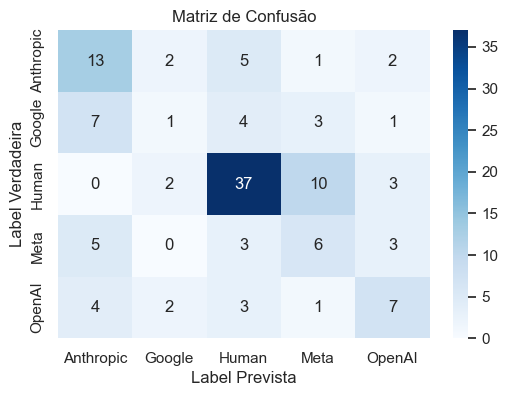

In [9]:
ficheiro = r"..\data\raw\dataset-exemplos.csv"

# 1. Obter a MELHOR combinação do passo anterior
melhor_combinacao = df_resultados.iloc[0]
print(f"🥇 A usar a melhor combinação: ID {melhor_combinacao['Combinação ID']}")
print(f"Ficheiros: {melhor_combinacao['Ficheiros Utilizados']}\n")

# 2. Carregar e treinar no DATASET COMPLETO da melhor combinação
comb_id_melhor = int(melhor_combinacao['Combinação ID'])
comb_escolhida = next((c for c in lista if c['comb_id'] == comb_id_melhor), None)

if comb_escolhida is None:
    raise ValueError(f"Combinação ID {comb_id_melhor} não encontrada em 'lista'.")

df_treino_final = comb_escolhida['dataframe'][colunas_base].copy()
X_treino_final = df_treino_final['Text']
y_treino_final = df_treino_final['Label']

print("A treinar modelo final com 100% dos dados da melhor combinação...")
vectorizer_final = TfidfVectorizer(max_features=3000, stop_words='english')
X_treino_final_vec = vectorizer_final.fit_transform(X_treino_final)

modelo_final = LogisticRegression(max_iter=500, random_state=42)
modelo_final.fit(X_treino_final_vec, y_treino_final)

# 3. Carregar o dataset e Avaliar
try:
    df_teste = pd.read_csv(ficheiro, sep=';')
    
    if set(colunas_base).issubset(df_teste.columns):
        X_teste_prof = df_teste['Text']
        y_teste_prof_true = df_teste['Label']
        
        # Transformar com o vectorizer treinado 
        X_teste_prof_vec = vectorizer_final.transform(X_teste_prof)
        
        # Prever
        y_pred_prof = modelo_final.predict(X_teste_prof_vec)
        
        # Apresentar Resultados Finais
        print("🎯 Resultados finais:")
        print(classification_report(y_teste_prof_true, y_pred_prof))
        
        # Matriz de Confusão
        cm = confusion_matrix(y_teste_prof_true, y_pred_prof)
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=modelo_final.classes_, 
                    yticklabels=modelo_final.classes_)
        plt.title('Matriz de Confusão')
        plt.ylabel('Label Verdadeira')
        plt.xlabel('Label Prevista')
        plt.show()
    else:
        print(f"❌ O dataset não tem as colunas {colunas_base}.")
        
except FileNotFoundError:
    print(f"❌ ERRO: Ficheiro '{ficheiro}' não encontrado. Altera a variável 'ficheiro' para o caminho correto.")